
--Classification Result (Iris)--
Accuracy:  1.0


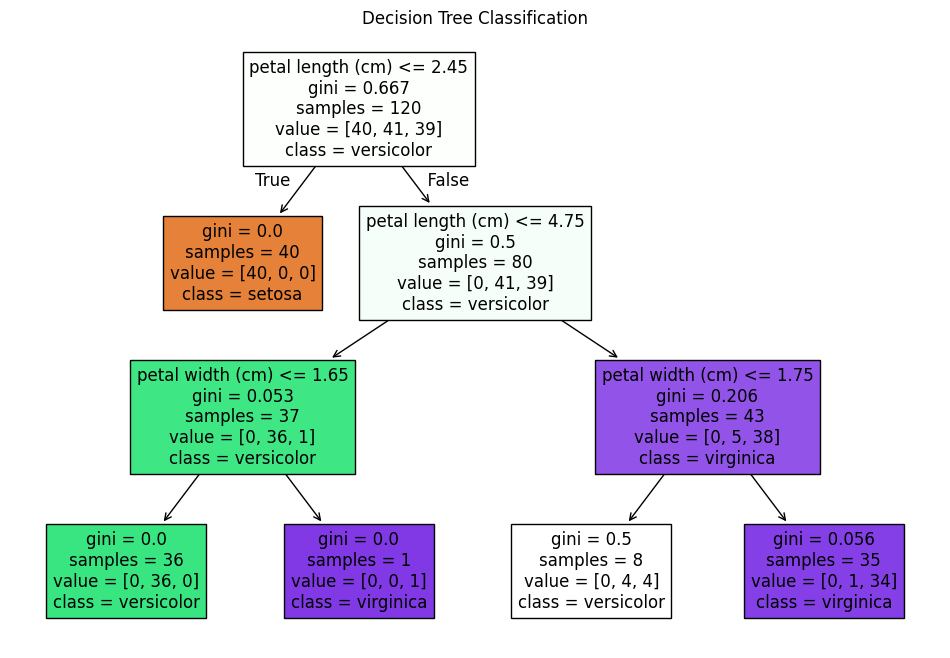


--Regression Result (California Housing)--
Mean Absolute Error:  0.5222592972077786
R2 Score:  0.5997321244428706


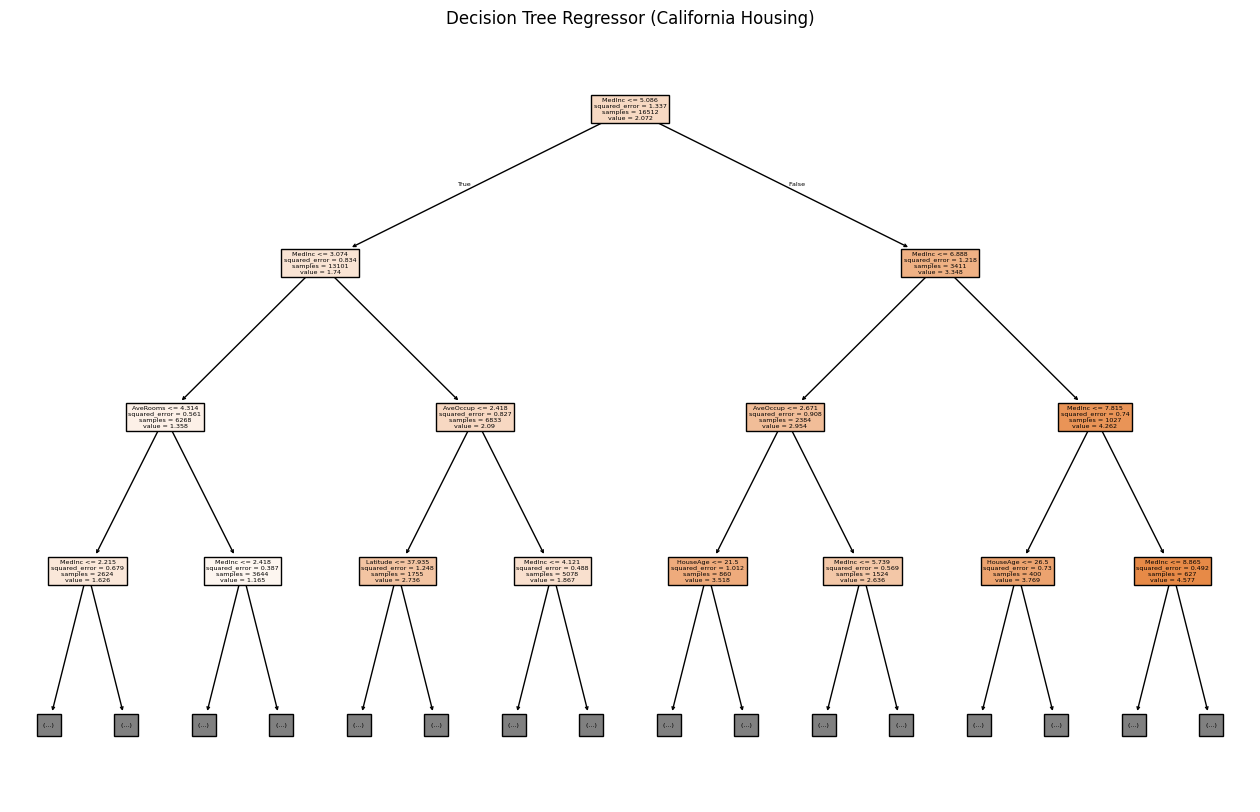

In [17]:
# Import libraries
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For plotting the decision tree
from sklearn import tree # For Decision Tree model
from sklearn.datasets import load_iris, fetch_california_housing # To load Iris dataset
from sklearn.model_selection import train_test_split # To split data
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score # To calculate accuracy

# Classify flowers
def decision_tree_classification():
    # 1. Load the iris dataset
    iris = load_iris()

    # X = features (flower measurement)
    # y = target (flower species)
    X, y = iris.data, iris.target

    # 2. Split dataset into training (80%) and tesing (20% = 0.2)
    # random_state=42 ensures same split every time we run the code
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state = 42
    )
    
    # 3. Create Decision Tree model
    clf = tree.DecisionTreeClassifier(max_depth = 3, random_state = 42)

    # 4. Train the model using training data
    clf.fit(X_train, y_train)

    # 5. Make predictions using test data
    y_pred = clf.predict(X_test)

    # 6. Calculate accuracy (how many predictions are correct)
    accuracy = accuracy_score(y_test, y_pred)

    # 7. Print Classification Result
    print("\n--Classification Result (Iris)--")
    print("Accuracy: ", accuracy)

    # Visualize the Decision Tree
    plt.figure(figsize = (12, 8))
    tree.plot_tree(
        clf,
        filled = True, # Color nodes by class
        feature_names = iris.feature_names, # Show features names
        class_names = iris.target_names # Show class names
    )
    plt.title("Decision Tree Classification")
    plt.show()

# Predicts house prices
def decision_tree_regression():
    # Load dataset
    housing = fetch_california_housing()

    # X = Features (Housing information)
    # y = Target (housing price)
    X, y = housing.data, housing.target

    # Split dataset into train = 80% and test = 20%
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state = 42
    )

    # Create decision Tree model
    reg = tree.DecisionTreeRegressor(max_depth = 5, random_state = 42)

    # Train
    reg.fit(X_train, y_train)

    # Test
    y_pred = reg.predict(X_test)

    # MAE = Averge dollar mistake
    mae = mean_absolute_error(y_test, y_pred)
    # R2 = How much pattern model understands
    r2 = r2_score(y_test, y_pred)

    # Print the Result
    print("\n--Regression Result (California Housing)--")
    print("Mean Absolute Error: ", mae)
    print("R2 Score: ", r2)

    plt.figure(figsize = (16, 10))
    tree.plot_tree(
        reg,
        filled = True,
        feature_names = housing.feature_names,
        max_depth = 3# display only top level
    )
    plt.title("Decision Tree Regressor (California Housing)")
    plt.show()

if __name__ == "__main__":
    decision_tree_classification()
    decision_tree_regression()